In [31]:
import pandas as pd
import seaborn as sns 
import requests
import numpy as np

In [7]:
kraken2_out = pd.read_csv("../results/2025-03-06-kraken2-test/PV64_21351_kraken-standard.out", sep="\t", header=None, index_col=None, names=['is_classified', 'seq_id',  'taxonid', '_1', '_2'])
kraken2_out[:10]

,is_classified,seq_id,taxonid,_1,_2
0,U,J00148:56:HM5WHBBXX:1:1101:1296:1244,0,151|151,A:1 0:20 A:89 0:7 |:| A:67 0:21 A:29
1,U,J00148:56:HM5WHBBXX:1:1101:2656:1244,0,151|151,0:21 A:95 0:1 |:| A:67 0:20 A:30
2,U,J00148:56:HM5WHBBXX:1:1101:2717:1244,0,151|151,0:21 A:95 0:1 |:| A:67 0:20 A:30
3,U,J00148:56:HM5WHBBXX:1:1101:2757:1244,0,151|151,0:21 A:95 0:1 |:| A:67 0:20 A:30
4,U,J00148:56:HM5WHBBXX:1:1101:3650:1244,0,151|151,0:21 A:95 0:1 |:| A:67 0:20 A:30
5,U,J00148:56:HM5WHBBXX:1:1101:7202:1244,0,151|151,0:12 A:105 |:| A:67 0:12 A:38
6,U,J00148:56:HM5WHBBXX:1:1101:13210:1244,0,151|151,0:10 A:107 |:| A:70 0:8 A:39
7,U,J00148:56:HM5WHBBXX:1:1101:13738:1244,0,151|151,0:10 A:107 |:| A:70 0:8 A:39
8,U,J00148:56:HM5WHBBXX:1:1101:15483:1244,0,151|151,0:10 A:107 |:| A:70 0:5 A:42
9,U,J00148:56:HM5WHBBXX:1:1101:17066:1244,0,151|151,0:10 A:107 |:| A:70 0:5 A:42


In [9]:
kraken2_out = kraken2_out[['is_classified', 'taxonid']]

In [11]:
kraken2_out.value_counts(subset='is_classified').reset_index()

,is_classified,count
0,U,8039119
1,C,2048038


In [23]:
most_found = kraken2_out.query('is_classified == "C"').value_counts('taxonid')[:20].copy().reset_index()

In [20]:
def obtain_report(taxid):
    u = requests.get(f"https://api.ncbi.nlm.nih.gov/datasets/v2/genome/taxon/{taxid}/dataset_report")
    u.raise_for_status()
    u = u.json()
    try:
        u = u['reports'][0]['organism']['organism_name']
    except KeyError:
        return dict(taxid=taxid, organism=None)
    return u


In [25]:
most_found['scientific name'] = most_found['taxonid'].apply(obtain_report)

In [32]:
most_found['logcount'] = most_found['count'].apply(np.log10)

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


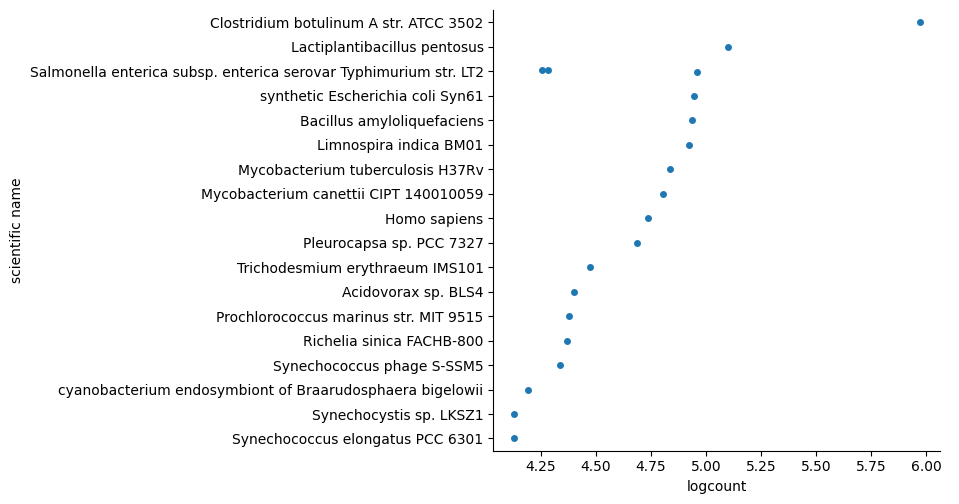

In [35]:
sns.catplot(y='scientific name', x='logcount', data=most_found)

In [40]:
all_found = kraken2_out.query('is_classified == "C"').value_counts('taxonid').copy().reset_index().reset_index()
all_found['logcount'] = all_found['count'].apply(np.log10)
all_found[:10]

,index,taxonid,count,logcount
0,0,1491,935771,5.971170
1,1,1589,126221,5.101132
2,2,2,91417,4.961027
3,3,28384,87752,4.943257
4,4,1390,86389,4.936458
5,5,2760438,84097,4.924781
6,6,1783272,68849,4.837898
7,7,78331,63974,4.806004
8,8,9606,54621,4.737360
9,9,118163,48475,4.685518


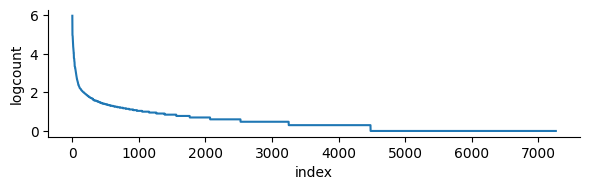

In [43]:
sns.relplot(x='index', y='logcount', data=all_found, kind='line', height=2.0, aspect=3.0)